In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub
import os
import osmnx as ox
import geopandas as gpd
from pandas import DataFrame

plt.style.use("seaborn-v0_8")

In [207]:
apartments = pd.read_csv("../data/apartments.csv")
apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
0,80.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,62.0,Furnished,16,District Heating,1.290323,43.850305,18.374470
1,100.0,Vogošća,New Build,Rent,2.0,20.0,Furnished,-1,Central (Boiler Room),5.000000,43.901206,18.354117
2,160.0,Trnovo,New Build,Rent,2.0,50.0,Furnished,0,Electric Heating,3.200000,43.714503,18.288786
3,200.0,Sarajevo - Novi Grad,Good Condition,Rent,1.0,30.0,Furnished,1,Central (Boiler Room),6.666667,43.800453,18.246421
4,250.0,Sarajevo - Novo Sarajevo,Good Condition,Rent,2.0,48.0,Unfurnished,0,Electric Heating,5.208333,43.858893,18.399583
...,...,...,...,...,...,...,...,...,...,...,...,...
845,1000000.0,Sarajevo - Centar,Good Condition,Sale,3.0,124.0,Unfurnished,0,Gas Heating,8064.516129,43.853746,18.404423
846,1050000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,146.0,Furnished,8,Central (Boiler Room),7191.780822,43.846929,18.374245
847,1191000.0,Sarajevo - Novo Sarajevo,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,43.846926,18.374029
848,1191000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,43.847530,18.375606


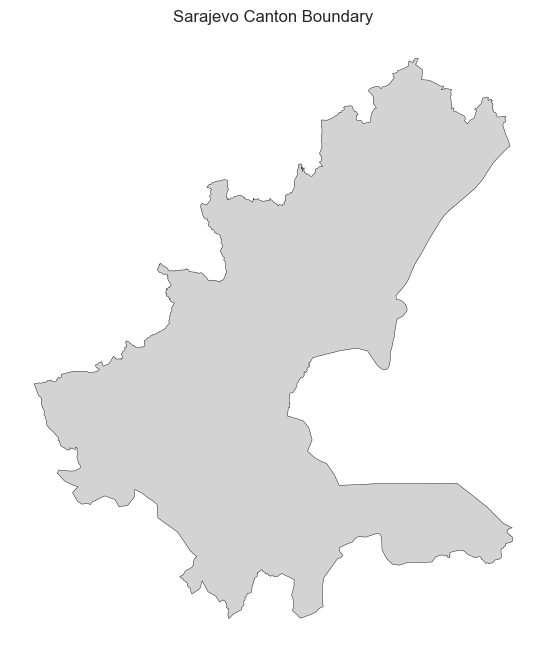

EPSG:32634


In [208]:
place = "Sarajevo Canton, Bosnia and Herzegovina"

canton = ox.geocode_to_gdf(place).to_crs(epsg=32634)

fig, ax = plt.subplots(figsize=(8, 8))
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
ax.set_title("Sarajevo Canton Boundary")
ax.axis("off")
plt.show()

print(canton.crs)

In [209]:
apartments_gdf = gpd.GeoDataFrame(
    apartments,
    geometry=gpd.points_from_xy(apartments['longitude'], apartments['latitude'], crs="EPSG:4326"),
    crs="EPSG:4326"
).to_crs("EPSG:32634")

apartments_clipped = apartments_gdf.clip(canton)


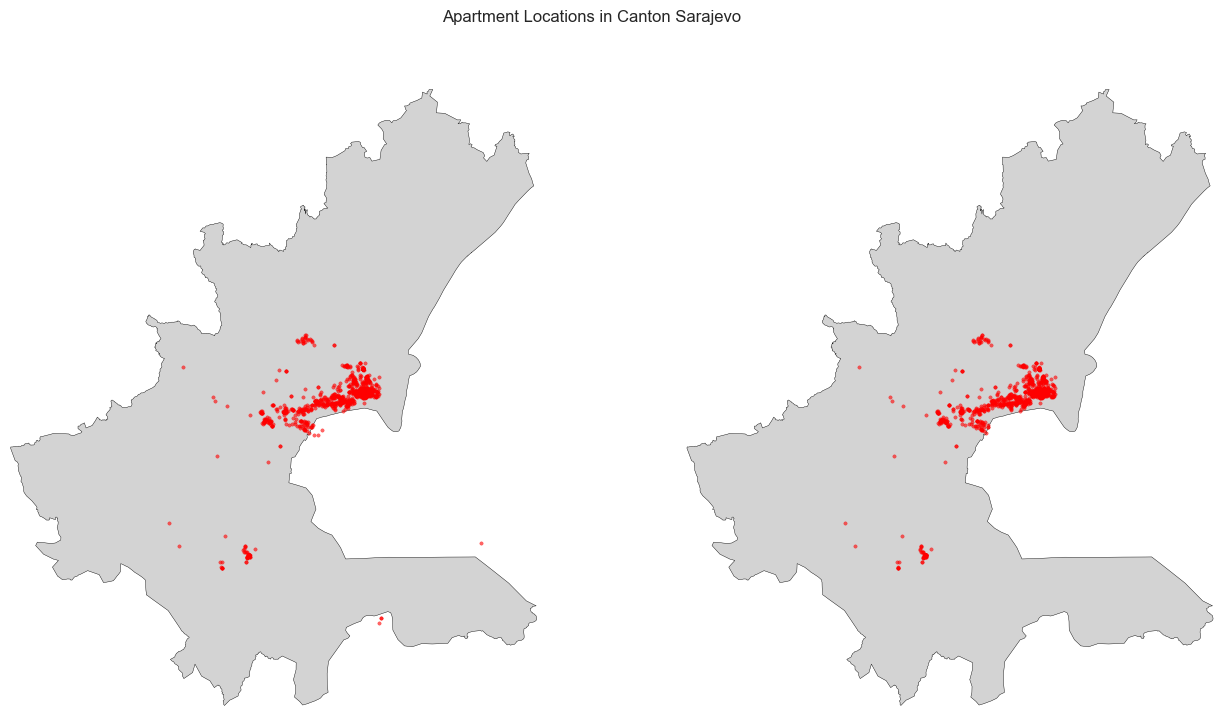

In [210]:
minx, miny, maxx, maxy = canton.total_bounds

plt.subplots(figsize=(16, 8), nrows=1, ncols=2)

ax = plt.subplot(1,2,1)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
apartments_gdf.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.6
)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

ax = plt.subplot(1,2,2)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
apartments_clipped.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.6
)

# Force view to canton extent
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

plt.suptitle("Apartment Locations in Canton Sarajevo")
plt.show()

In [211]:
removed_apartments = apartments.loc[
    ~apartments.index.isin(apartments_clipped.index)
]

removed_apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
14,400.0,Sarajevo - Novi Grad,New Build,Rent,1.0,35.0,Furnished,3,Central Gas Heating,11.428571,43.820528,18.360500
40,550.0,Sarajevo - Centar,Good Condition,Rent,1.0,38.0,Furnished,4,District Heating,14.473684,44.770647,17.213587
47,550.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,44.0,Furnished,4,District Heating,12.500000,43.825377,18.369031
68,650.0,Sarajevo - Novi Grad,New Build,Rent,3.0,86.0,Semi-Furnished,4,District Heating,7.558140,43.820686,18.365006
107,750.0,Ilidža,New Build,Rent,3.0,57.0,Furnished,6,District Heating,13.157895,43.827596,18.357962
121,800.0,Sarajevo - Novi Grad,New Build,Rent,3.0,64.0,Furnished,4,Central Gas Heating,12.500000,43.829350,18.358322
323,142000.0,Sarajevo - Novi Grad,Good Condition,Sale,2.0,57.3,Furnished,6,Electric Heating,2478.184991,41.194595,19.523676
324,144100.0,Sarajevo - Novi Grad,New Build,Sale,2.0,53.0,Unfurnished,2,Electric Heating,2718.867925,41.232957,19.521073
326,149500.0,Trnovo,New Build,Sale,2.0,30.0,Semi-Furnished,1,Electric Heating,4983.333333,43.665483,18.446512
381,205816.0,Trnovo,Under Construction,Sale,2.0,39.0,Unfurnished,2,Electric Heating,5277.333333,43.661107,18.443999


In [212]:
POI_TAGS = {
    # Healthcare
    "hospital": {"amenity": "hospital"},
    "clinic": {"amenity": "clinic"},
    "pharmacy": {"amenity": "pharmacy"},

    # Education
    "school": {"amenity": "school"},
    "university": {"amenity": "university"},
    "kindergarten": {"amenity": "kindergarten"},

    # Transport
    "bus_stop": {"highway": "bus_stop"},
    "tram_stop": {"railway": "tram_stop"},
    "train_station": {"railway": "station"},
    "parking": {"amenity": "parking"},

    # Environment
    "park": {"leisure": "park"},
    "playground": {"leisure": "playground"},

    # Commerce
    "mall": {"shop": "mall"},
    "supermarket": {"shop": "supermarket"},
    "marketplace": {"amenity": "marketplace"},

    # Urban
    "restaurant": {"amenity": "restaurant"},
    "cafe": {"amenity": "cafe"},

    # Religion
    "place_of_worship": {"amenity": "place_of_worship"},

    # Safety & public services
    "police": {"amenity": "police"},
    "fire_station": {"amenity": "fire_station"},
    "post_office": {"amenity": "post_office"},

    # Sports & lifestyle
    "sports_centre": {"leisure": "sports_centre"},
    "fitness_centre": {"leisure": "fitness_centre"},
    "stadium": {"leisure": "stadium"},
}

In [213]:
poi_data = {}

for name, tags in POI_TAGS.items():
    gdf = ox.features.features_from_place(place, tags).to_crs(epsg=32634)
    # Keep only points (some POIs are polygons)
    gdf = gdf[gdf.geometry.type.isin(["Point", "Polygon"])]

    # Convert polygons to centroids
    gdf["geometry"] = gdf.geometry.centroid

    poi_data[name] = gdf

<Figure size 1000x800 with 0 Axes>

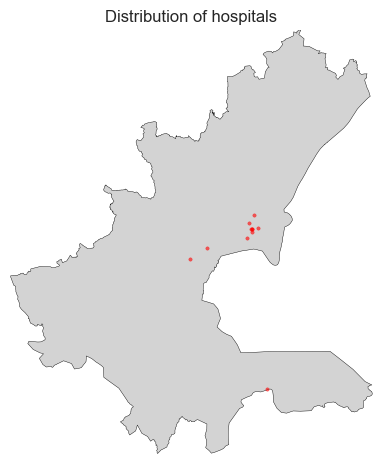

<Figure size 1000x800 with 0 Axes>

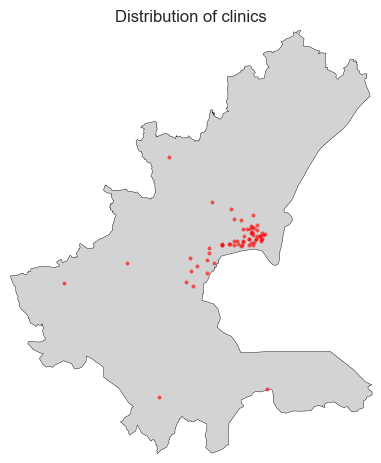

<Figure size 1000x800 with 0 Axes>

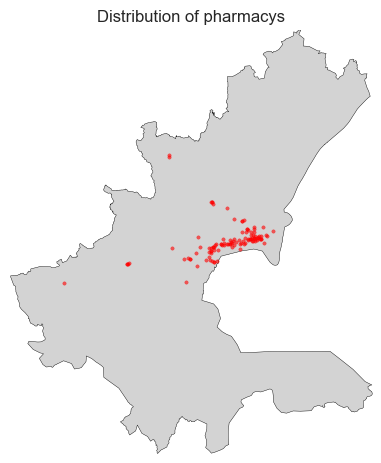

<Figure size 1000x800 with 0 Axes>

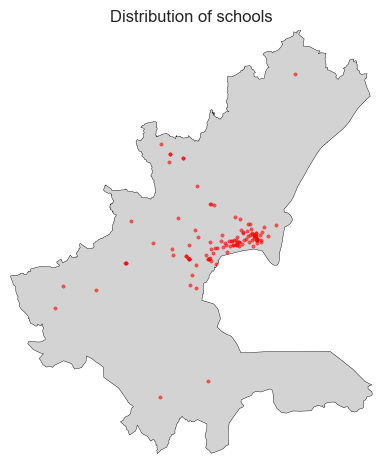

<Figure size 1000x800 with 0 Axes>

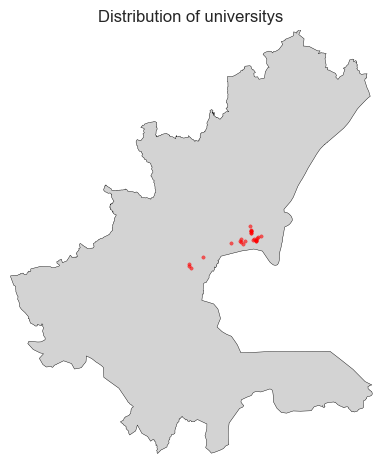

<Figure size 1000x800 with 0 Axes>

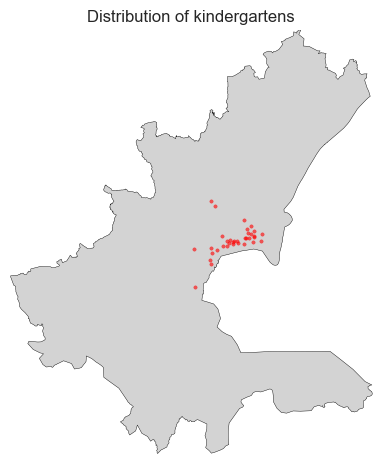

<Figure size 1000x800 with 0 Axes>

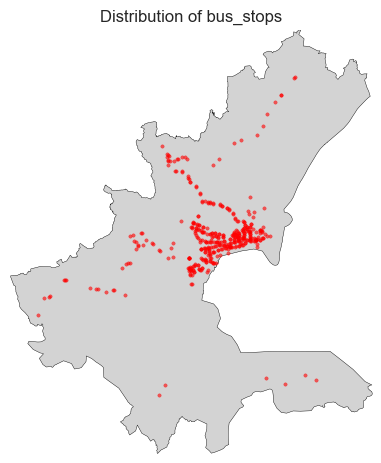

<Figure size 1000x800 with 0 Axes>

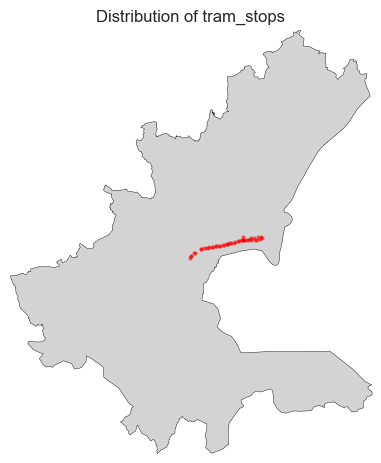

<Figure size 1000x800 with 0 Axes>

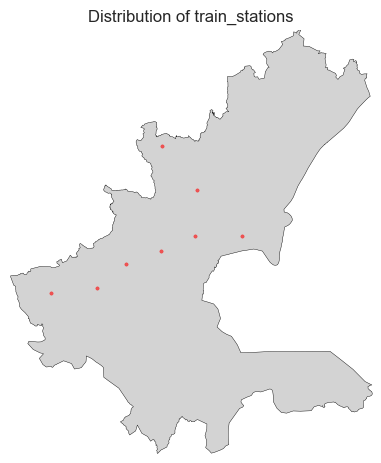

<Figure size 1000x800 with 0 Axes>

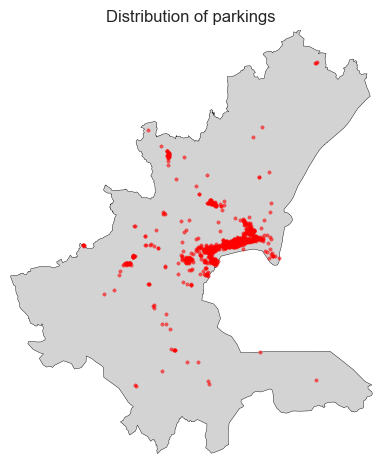

<Figure size 1000x800 with 0 Axes>

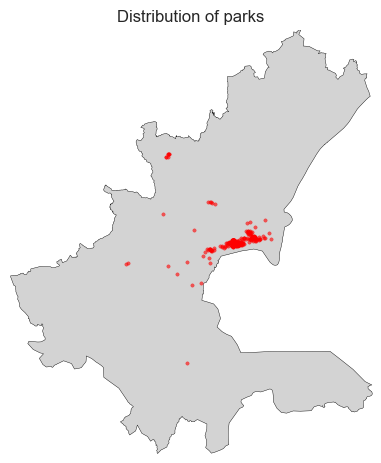

<Figure size 1000x800 with 0 Axes>

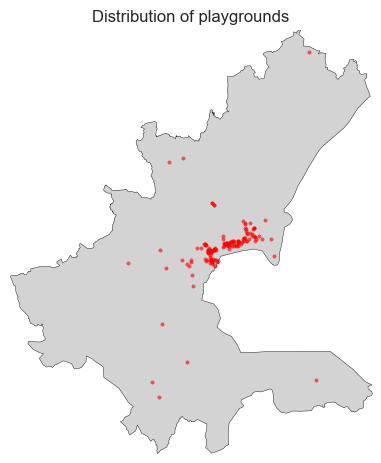

<Figure size 1000x800 with 0 Axes>

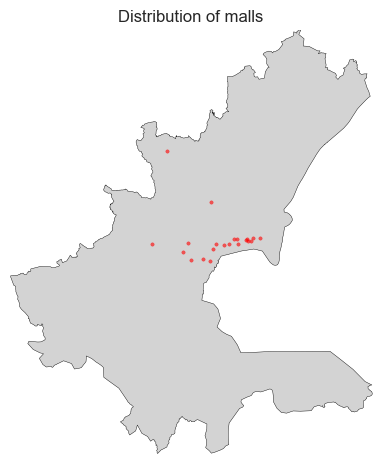

<Figure size 1000x800 with 0 Axes>

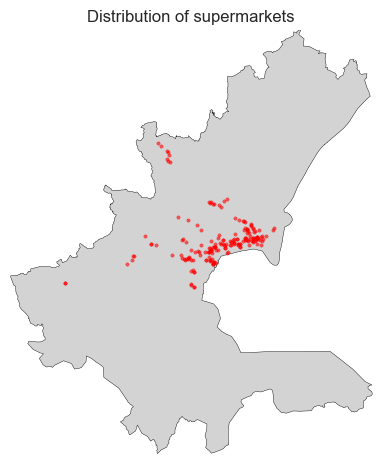

<Figure size 1000x800 with 0 Axes>

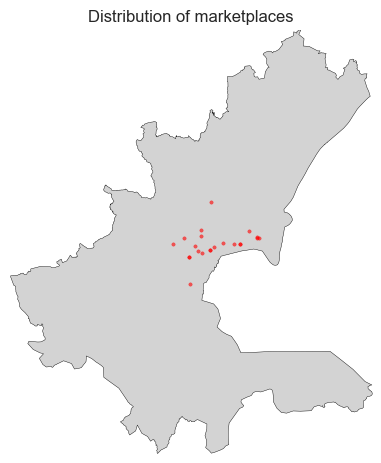

<Figure size 1000x800 with 0 Axes>

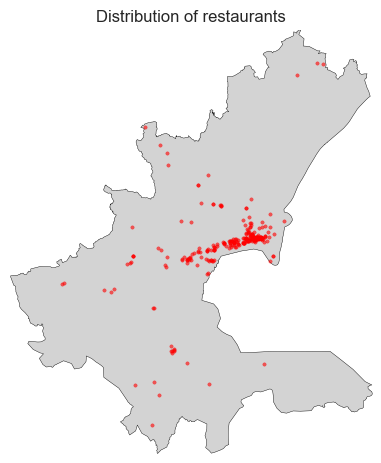

<Figure size 1000x800 with 0 Axes>

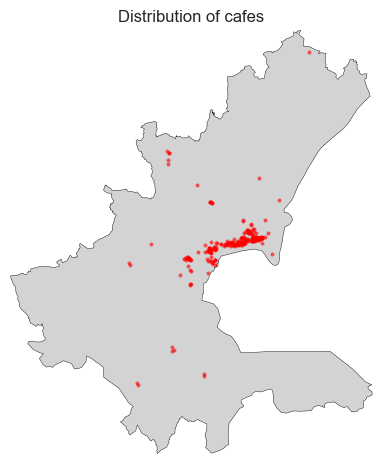

<Figure size 1000x800 with 0 Axes>

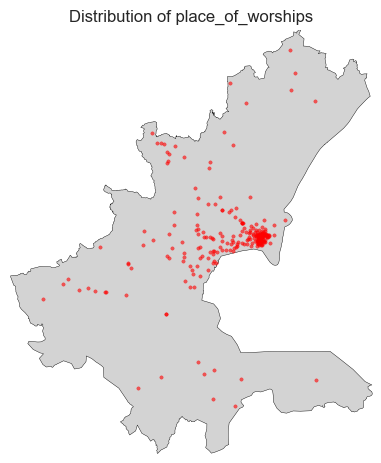

<Figure size 1000x800 with 0 Axes>

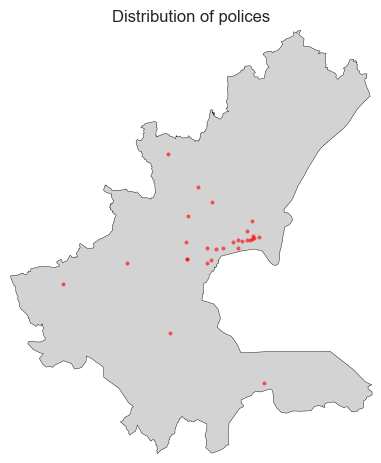

<Figure size 1000x800 with 0 Axes>

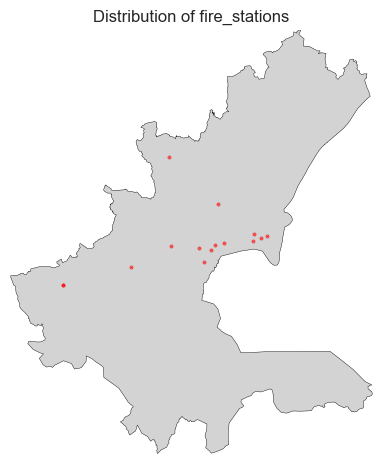

<Figure size 1000x800 with 0 Axes>

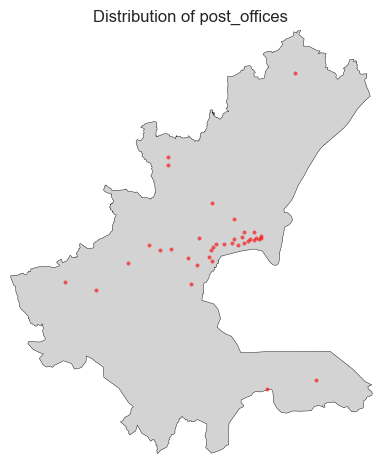

<Figure size 1000x800 with 0 Axes>

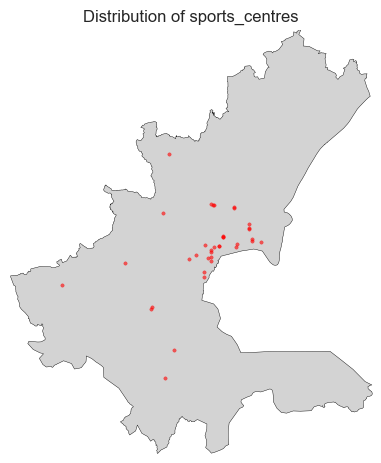

<Figure size 1000x800 with 0 Axes>

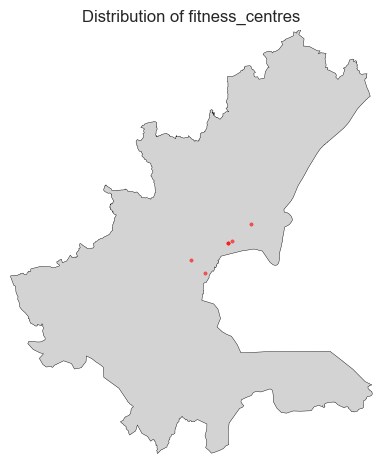

<Figure size 1000x800 with 0 Axes>

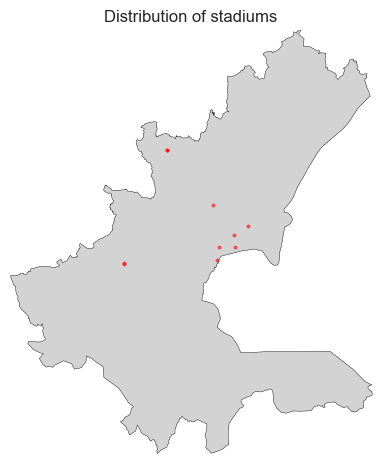

In [214]:
for feature in poi_data.keys():
    plt.figure(figsize=(10, 8))
    ax = canton.plot(facecolor="lightgrey", edgecolor="black")
    poi_data[feature].plot(ax=ax, color="red", markersize=6, alpha=0.6)
    ax.set_xlim(minx, maxx);ax.set_ylim(miny, maxy);ax.axis("off")
    plt.title(f"Distribution of {feature}s")
    plt.show()
    plt.close()

In [215]:
poi_data['bus_stop'].dropna(axis="columns", how="any").explore()

In [216]:
from shapely.geometry import Point

def compute_distance(s : pd.Series):
    # Create point in WGS84
    point = Point(s["longitude"], s["latitude"])
    point = gpd.GeoSeries([point], crs="EPSG:4326").to_crs(epsg=32634).iloc[0]

    for poi_name, pois in poi_data.items():
        if pois.empty:
            s[f"closest_{poi_name}_m"] = np.nan
            continue

        idx = pois.sindex.nearest(point, 1)[1][0]
        nearest_geom = pois.geometry.iloc[idx]

        s[f"closest_{poi_name}_m"] = point.distance(nearest_geom)

    return s

apartments = apartments.apply(compute_distance, axis="columns")

In [217]:
apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,...,closest_marketplace_m,closest_restaurant_m,closest_cafe_m,closest_place_of_worship_m,closest_police_m,closest_fire_station_m,closest_post_office_m,closest_sports_centre_m,closest_fitness_centre_m,closest_stadium_m
0,80.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,62.0,Furnished,16,District Heating,1.290323,...,699.392958,306.564487,107.422423,129.794899,759.774769,585.917857,486.063763,1197.074760,132.957100,1124.268280
1,100.0,Vogošća,New Build,Rent,2.0,20.0,Furnished,-1,Central (Boiler Room),5.000000,...,913.563178,434.723961,755.559272,419.039500,818.071943,231.747137,773.439330,614.725015,5441.243450,660.564602
2,160.0,Trnovo,New Build,Rent,2.0,50.0,Furnished,0,Electric Heating,3.200000,...,9559.267559,98.131182,191.595278,3601.693859,2609.020979,12946.232770,9539.668920,189.067767,11568.714680,13912.995870
3,200.0,Sarajevo - Novi Grad,Good Condition,Rent,1.0,30.0,Furnished,1,Central (Boiler Room),6.666667,...,5272.969553,2735.716453,3850.725980,3505.345231,4372.132157,3584.924484,4276.312216,3581.527303,6122.653017,4640.315510
4,250.0,Sarajevo - Novo Sarajevo,Good Condition,Rent,2.0,48.0,Unfurnished,0,Electric Heating,5.208333,...,975.041615,27.802543,132.096470,530.258146,410.916870,1528.918025,96.005742,1166.499307,1559.165284,1200.841719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,1000000.0,Sarajevo - Centar,Good Condition,Sale,3.0,124.0,Unfurnished,0,Gas Heating,8064.516129,...,821.438817,229.252303,132.225477,353.675257,413.726682,1101.027202,222.911725,860.096536,1886.891070,1575.493999
846,1050000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,146.0,Furnished,8,Central (Boiler Room),7191.780822,...,829.797090,233.133205,207.746203,475.112876,712.778449,727.545263,566.332684,1175.620556,500.246136,1065.628626
847,1191000.0,Sarajevo - Novo Sarajevo,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,...,815.982295,247.693157,202.877680,473.170946,695.746641,714.447207,552.348271,1182.165118,499.863464,1082.980684
848,1191000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,...,825.514846,212.280383,194.116910,434.906606,835.043153,778.954701,629.169812,1065.172378,452.600572,960.966915


<Axes: xlabel='closest_clinic_m', ylabel='Count'>

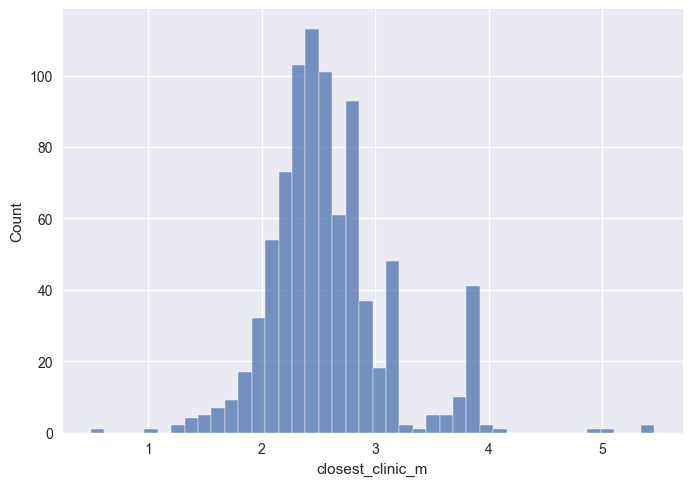

In [218]:
sns.histplot(apartments['closest_clinic_m'].map(np.log10))
#sns.displot(data=apartments['closest_tram_stop_m'].map(np.log), x="closest_tram_stop_m", hue="ad_type")

<Axes: >

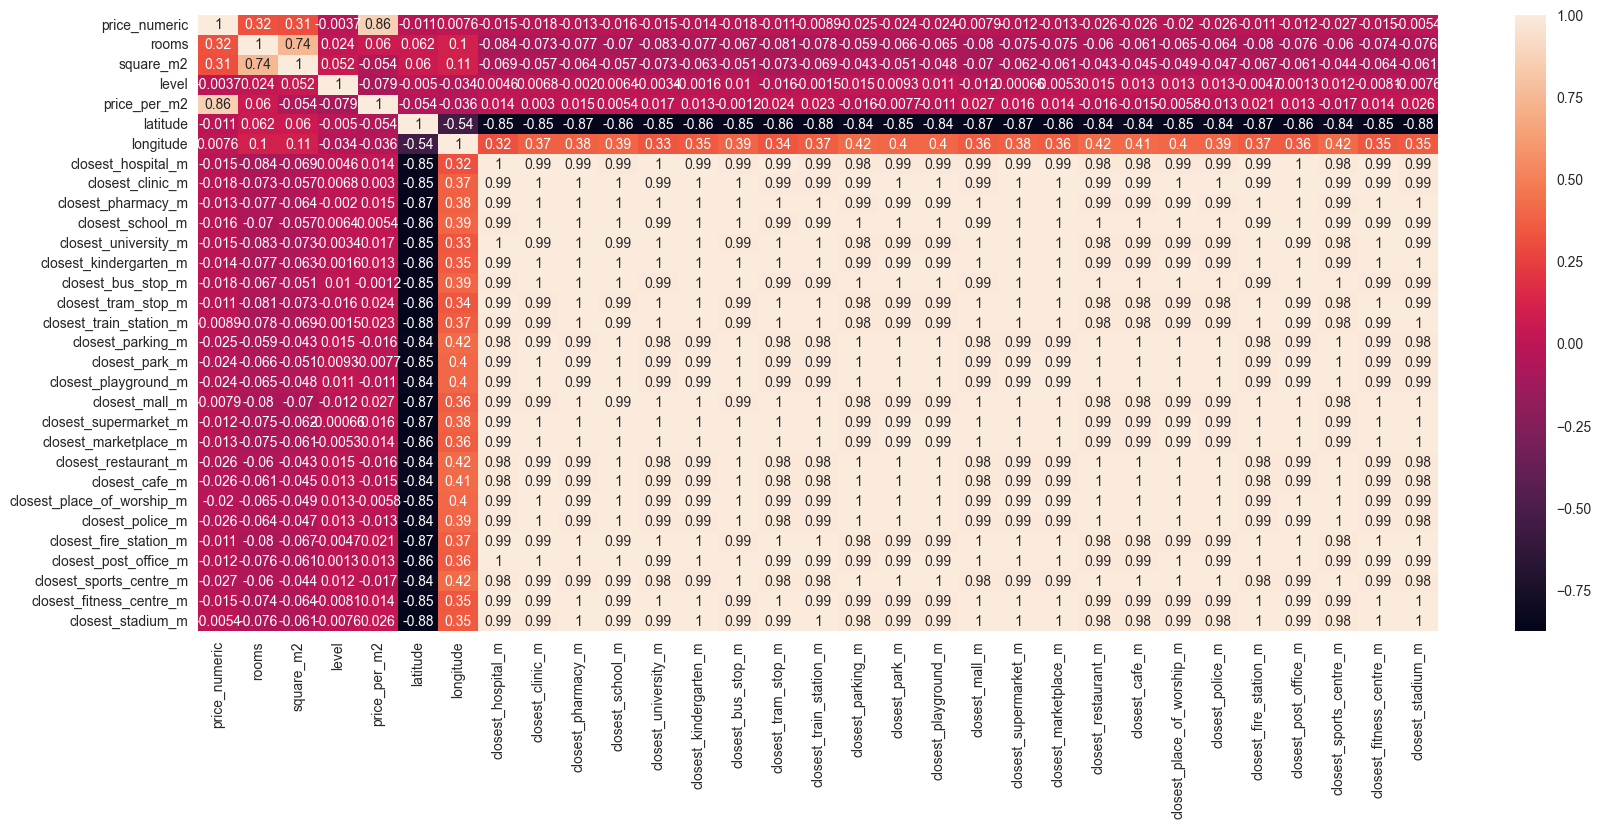

In [219]:
plt.figure(figsize=(20, 8))
sns.heatmap(data=apartments.corr(numeric_only=True), annot=True)

<Axes: >

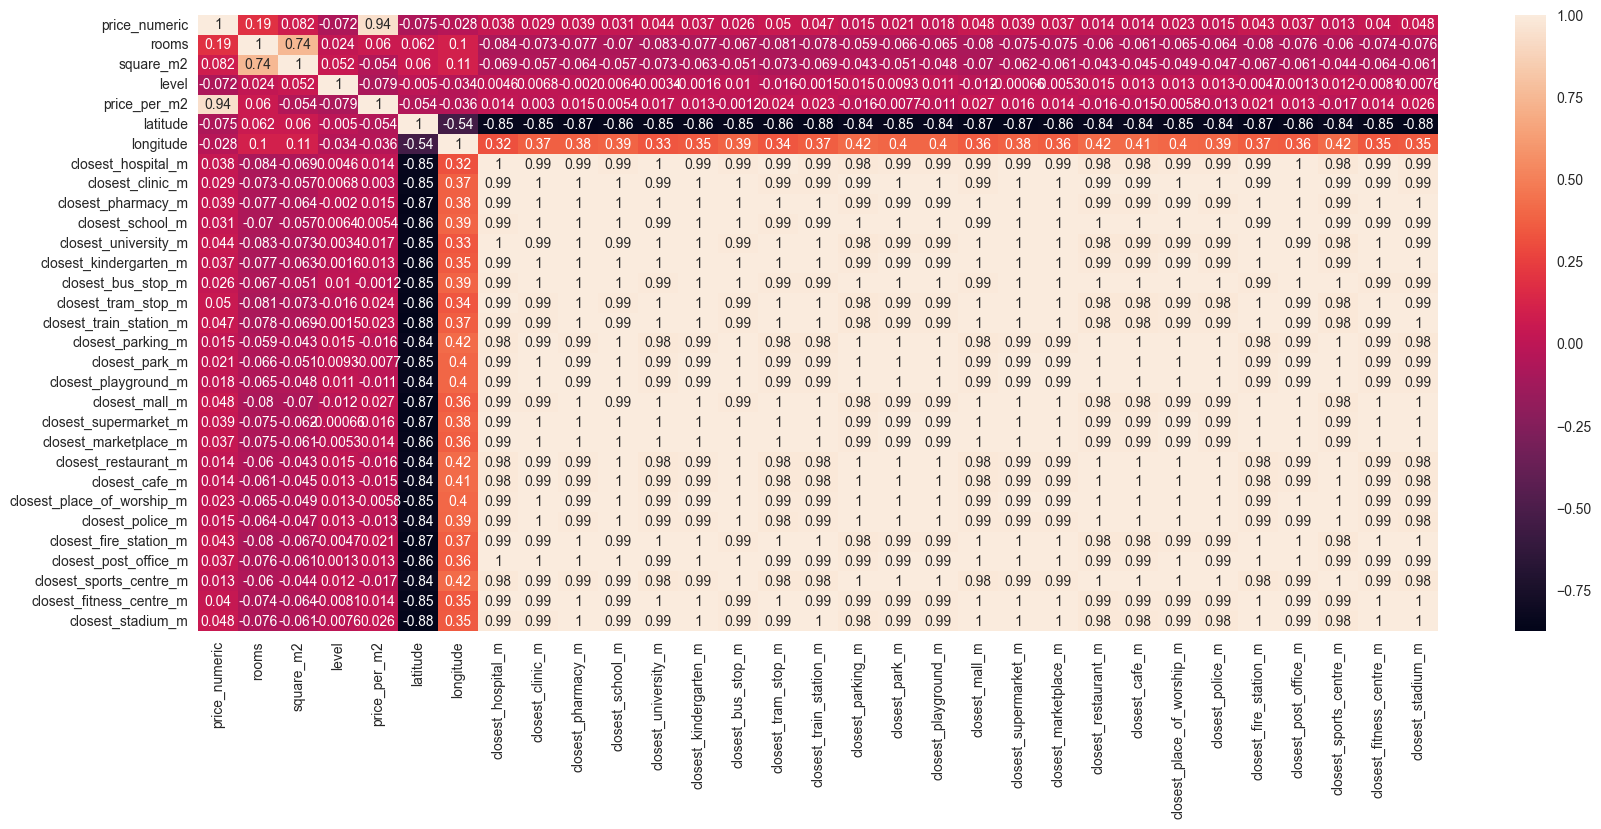

In [220]:
log_price_apartments = apartments.copy()
log_price_apartments['price_numeric'] = np.log(log_price_apartments['price_numeric'])
plt.figure(figsize=(20, 8))
sns.heatmap(data=log_price_apartments.corr(numeric_only=True), annot=True)


In [221]:
apartments.drop(labels=["latitude", "longitude"], axis=1, inplace=True)

sales = apartments[apartments['ad_type'] == 'Sale'].drop(labels="ad_type", axis=1)
sales.to_csv("../data/sales.csv", index=False)

rentals = apartments[apartments['ad_type'] == 'Rent'].drop(labels="ad_type", axis=1)
sales.to_csv("../data/rentals.csv", index=False)